In [1]:
## importing libraries
import torch
import torch.nn as nn
import timm
from torchvision.datasets import ImageFolder
from torchvision.transforms import transforms
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
from torch.utils.data import Dataset,DataLoader,random_split
from tqdm.notebook import tqdm

/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

In [4]:
global_path = "/kaggle/input/trash-net/dataset-resized"

In [2]:
# setting device to cuda
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:",device)

Device: cuda


In [5]:
CLASS = {items:keys for keys,items in ImageFolder(global_path).class_to_idx.items()}
print(CLASS)

{0: 'cardboard', 1: 'glass', 2: 'metal', 3: 'paper', 4: 'plastic', 5: 'trash'}


In [6]:
## dataset class
class GarbageCollection(Dataset):
  def __init__(self,path,transform=None):
    self.data = ImageFolder(path,transform=transform)
  def __len__(self):
    return len(self.data)
  def __getitem__(self, index):
    return self.data[index]

In [7]:
# global dataset object
dataset = GarbageCollection(global_path)

In [8]:
## splitting into train test split
size = len(dataset)
train_size = int(0.7*size)
val_size = int(0.15*size)
test_size = int(size-train_size-val_size)

In [9]:
## Index
train_indices, val_indices, test_indices = random_split(
    range(len(dataset)), [train_size, val_size, test_size]
)
print(f"Training Index object :{train_indices}")
print(f"Testing Index object :{test_indices}")
print(f"Validation Index object :{val_indices}")

Training Index object :<torch.utils.data.dataset.Subset object at 0x7d128a0b4190>
Testing Index object :<torch.utils.data.dataset.Subset object at 0x7d128a09bfd0>
Validation Index object :<torch.utils.data.dataset.Subset object at 0x7d128a1aee90>


In [10]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

In [11]:
## getting the subset form global dataset
from torch.utils.data import Subset
train_dataset = Subset(GarbageCollection(global_path,transform=transform),train_indices)
test_dataset = Subset(GarbageCollection(global_path,transform=transform),test_indices)
val_dataset = Subset(GarbageCollection(global_path,transform=transform),val_indices)

In [12]:
len(train_dataset),len(test_dataset),len(val_dataset)

(1768, 380, 379)

In [13]:
(len(train_dataset)+len(test_dataset)+len(val_dataset)) == len(dataset)

True

In [14]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory = True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory = True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory = True
)

In [31]:
## creating the model 
class GarbageCollectionModel(nn.Module):
    def __init__(self, dropout_prob, num_classes=6):
        super(GarbageCollectionModel, self).__init__()
        # Where we define all the parts of the model
        self.base_model = timm.create_model('efficientnet_b0', pretrained=True)
        self.features = nn.Sequential(*list(self.base_model.children())[:-1])

        enet_out_size = 1280
        # Make a classifier
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(enet_out_size, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(p=dropout_prob),
            nn.Linear(128,num_classes)
        )
    
    def forward(self, x):
        # Connect these parts and return the output
        x = self.features(x)
        output = self.classifier(x)
        return output

In [16]:
model = GarbageCollectionModel(num_classes=len(CLASS))
print(str(model)[:500])

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

GarbageCollectionModel(
  (base_model): EfficientNet(
    (conv_stem): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn1): BatchNormAct2d(
      32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): SiLU(inplace=True)
    )
    (blocks): Sequential(
      (0): Sequential(
        (0): DepthwiseSeparableConv(
          (conv_dw): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=


In [17]:
for images,batch in train_loader:
    break

In [18]:
example_out = model(images)
example_out.shape # [batch_size, num_classes]

torch.Size([32, 6])

In [20]:
# Loss function
criterion = nn.CrossEntropyLoss()
# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [22]:
criterion(example_out, batch)
print(example_out.shape, batch.shape)

torch.Size([32, 6]) torch.Size([32])


In [38]:
# Simple training loop
num_epochs = 10
train_losses, val_losses = [], []
train_accuracy , val_accuracy = [],[]
accuracy = {}

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

model = GarbageCollectionModel(0.5,num_classes=len(CLASS))
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

for epoch in range(num_epochs):
    # Training phase
    model.train()
    running_loss = 0.0
    correct = 0
    for images, labels in tqdm(train_loader, desc='Training loop'):
        # Move inputs and labels to the device
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * labels.size(0)
        _,preds = torch.max(outputs,1)
        correct += (preds == labels).sum().item()
    train_loss = running_loss / len(train_loader.dataset)
    accuracy_training = correct/len(train_loader.dataset)
    train_accuracy.append(accuracy_training)
    train_losses.append(train_loss)
    
    # Validation phase
    model.eval()
    running_loss = 0.0
    correct = 0
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc='Validation loop'):
            # Move inputs and labels to the device
            images, labels = images.to(device), labels.to(device)
         
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * labels.size(0)
            _,preds = torch.max(outputs,1)
            correct += (preds == labels).sum().item()
    val_loss = running_loss / len(val_loader.dataset)
    accuracy_val = correct/len(val_loader.dataset)
    val_accuracy.append(accuracy_val)
    val_losses.append(val_loss)
    print(f"Epoch {epoch+1}/{num_epochs} - Train loss: {train_loss}, Validation loss: {val_loss} - Train accuracy: {accuracy_training}, Validation accuracy: {accuracy_val}")

Training loop:   0%|          | 0/56 [00:00<?, ?it/s]

Validation loop:   0%|          | 0/12 [00:00<?, ?it/s]

Epoch 1/10 - Train loss: 0.7854829465641695, Validation loss: 0.34172169128948904 - Train accuracy: 0.7347285067873304, Validation accuracy: 0.8944591029023746


Training loop:   0%|          | 0/56 [00:00<?, ?it/s]

Validation loop:   0%|          | 0/12 [00:00<?, ?it/s]

...

Validation loop:   0%|          | 0/12 [00:00<?, ?it/s]

Epoch 9/10 - Train loss: 0.17672726082114074, Validation loss: 0.39688003849542863 - Train accuracy: 0.9473981900452488, Validation accuracy: 0.8918205804749341


Training loop:   0%|          | 0/56 [00:00<?, ?it/s]

Validation loop:   0%|          | 0/12 [00:00<?, ?it/s]

Epoch 10/10 - Train loss: 0.16828734485002664, Validation loss: 0.4370947304061346 - Train accuracy: 0.9513574660633484, Validation accuracy: 0.8891820580474934


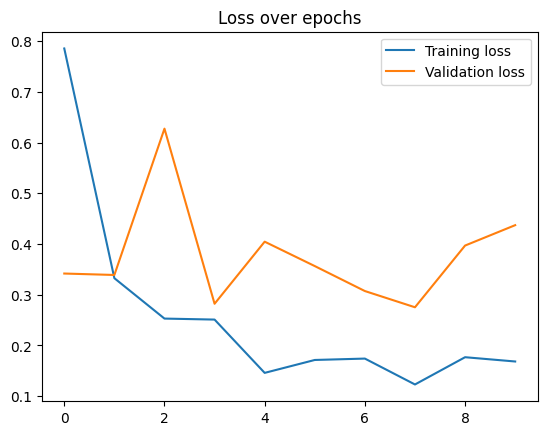

In [39]:
plt.plot(train_losses, label='Training loss')
plt.plot(val_losses, label='Validation loss')
plt.legend()
plt.title("Loss over epochs")
plt.show()

## see both losses are in decreasing and the difference is not also to big 

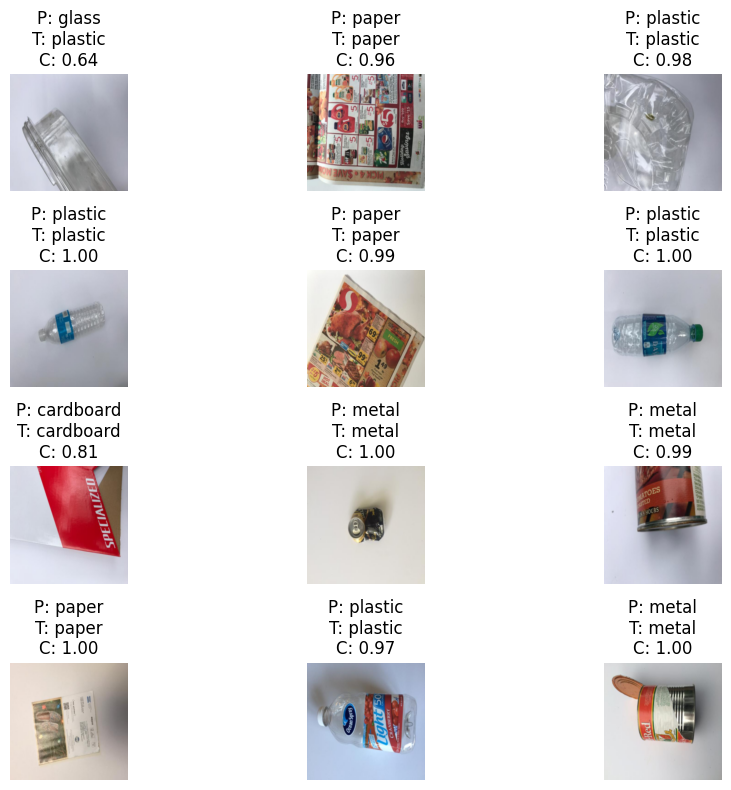

In [77]:
model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        preds = outputs.argmax(dim=1)
        probs = torch.softmax(outputs, dim=1)
        # print(probs)
        # print(preds)
        # print(probs[0,preds[0]])
        # break
        fig, ax = plt.subplots(4, 3, figsize=(10, 8))
        ax = ax.flatten()

        for i in range(min(len(images), 12)):
            img = images[i].cpu().permute(1, 2, 0)
            img = img.clamp(0, 1)

            pred_label = CLASS[preds[i].item()]
            true_label = CLASS[labels[i].item()]
            confidence = probs[i, preds[i]].item()

            ax[i].imshow(img)
            ax[i].set_title(
                f"P: {pred_label}\nT: {true_label}\nC: {confidence:.2f}"
            )
            ax[i].axis("off")

        plt.tight_layout()
        plt.show()
        break   # remove this to evaluate all batches


In [78]:
MODEL_PATH = "garbage_model.pth"
torch.save(model.state_dict(), MODEL_PATH)